# Image Compression Using K-Means 

## About

This notebook shows how to compress an image using K-Means and Machine Learning.

It uses an image that contains thousands of colors, and creates a compressed copy of it containing only the 16 colors that best group the pixels in the image.

### Languages and Frameworks involved

* __Python__ as main language.
* __Numpy__ for mathematical functions.
* __Scikit-Learn__ for Data Analysis.
* __PIL.Image__ for image handling.
* __os__ to get the size of the images.
* __Matplotlib__ for Data Visualization.

In [1]:
#Important Variables
image_name = "images/k_means_image_sample.jpg"
number_of_colors = 16

In [2]:
#Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.utils import shuffle
from PIL import Image

## Loading and Visualizing the Image

This step opens the image, and creates variables that will be used on the compression

The shape of the original image is: (873, 1164, 3)


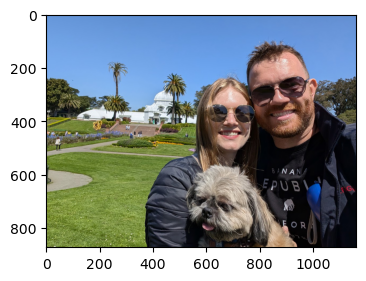

In [3]:
image = Image.open(image_name)
image_arr = np.array(image) / 255.0 #Normalizing the pixel values to [0, 1]
w, h, d = image_arr.shape

print("The shape of the original image is:", image_arr.shape)
plt.figure(figsize=(4, 4)) 
plt.imshow(image)

## Processing the Data

This step first reshapes the data into a (N, 3) array of pixels, where N = width * height of the image so it can be used by the KMeans algorithm. Each row will contain the Red, Green and Blue pixel values. 

Then it runs KMeans to fit and predict the best centroids.

And finally, it creates a compressed image using only the colors on these centroids.

In [4]:
image_array = np.reshape(image_arr, (w * h, d))

# Creating a subsample for faster training on large images
image_sample = shuffle(image_array, random_state=0, n_samples=25_000)

kmeans = KMeans(n_clusters=number_of_colors, random_state=0).fit(image_sample)

labels = kmeans.predict(image_array)

centroids = kmeans.cluster_centers_

compressed_img = centroids[labels].reshape(w, h, d)

## Visualizing the selected colors

The image below shows the palette of colors selected.

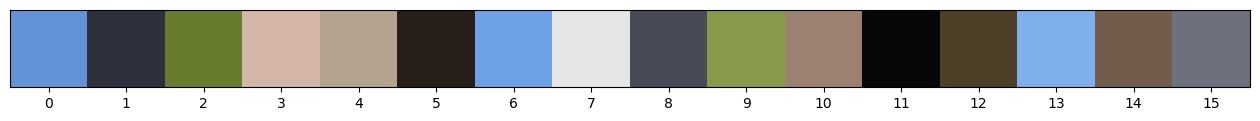

In [5]:
palette = np.expand_dims(centroids, axis=0)
num = np.arange(0,len(centroids))
plt.figure(figsize=(16, 16))
plt.xticks(num)
plt.yticks([])
plt.imshow(palette)

### Plot with the selected colors

The plot below shows the colors on the original image, and the Xs shows the colors picked by KMean as the centroids.

P.S.: It actually shows the colors in the sample, since the original image has too many colors and it was hard to see the Xs.

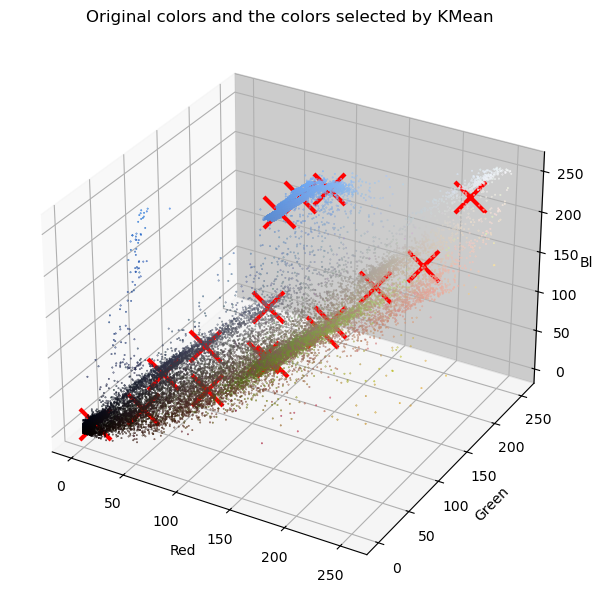

In [6]:
X = image_sample
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(221, projection='3d')
ax.scatter(*X.T*255, zdir='z', depthshade=False, s=.1, c=X, zorder=1)    
ax.scatter(*centroids.T*255, zdir='z', depthshade=False, s=500, c='red', marker='x', lw=3, zorder=10)    
ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')
ax.yaxis.set_pane_color((0., 0., 0., .2))
ax.set_title("Original colors and the colors selected by KMean")
plt.show()

## Result

### Original vs Compressed Image

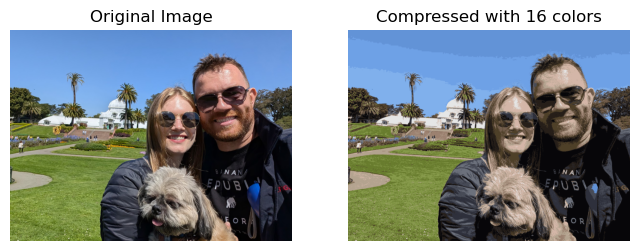

In [7]:
fig, ax = plt.subplots(1,2, figsize=(8,8))
plt.axis('off')

ax[0].imshow(image)
ax[0].set_title('Original Image')
ax[0].set_axis_off()

ax[1].imshow(compressed_img)
ax[1].set_title(f"Compressed with {number_of_colors} colors")
ax[1].set_axis_off()

### Difference in size

In [8]:
compressed_image_name = "images/k_means_image_sample_compressed.jpg"
Image.fromarray((compressed_img * 255).astype(np.uint8)).save(compressed_image_name)

original_size = os.path.getsize(image_name) / 1024
compressed_size = os.path.getsize(compressed_image_name) / 1024

print(f"Original Size: {original_size:.2f} KB.")
print(f"Compressed Size: {compressed_size:.2f} KB.")

Original Size: 293.56 KB.
Compressed Size: 183.80 KB.
